In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

print("TensorFlow/Keras imported.")

TensorFlow/Keras imported.


In [2]:
def load_and_reshape_data(csv_path, shape=(72, 48, 1), is_train=True):
    print(f"Loading and reshaping data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
        
        ids = df['ID']
        if is_train:
            labels = df['target']
            feature_cols = [col for col in df.columns if col.startswith('f_')]
            features_flat = df[feature_cols].values
        else:
            labels = None
            feature_cols = [col for col in df.columns if col.startswith('f_')]
            features_flat = df[feature_cols].values
            
        print(f"Found {features_flat.shape[1]} feature columns.")
        if features_flat.shape[1] != shape[0] * shape[1]:
             raise ValueError(f"Incorrect number of features found ({features_flat.shape[1]}) for shape {shape[:2]}. Expected {shape[0] * shape[1]}.")

        features_reshaped = features_flat.reshape(-1, shape[0], shape[1], shape[2])
        print(f"Data reshaped to: {features_reshaped.shape}")

        return ids, features_reshaped, labels

    except FileNotFoundError:
        print(f"ERROR: File not found at {csv_path}")
        return None, None, None
    except Exception as e:
        print(f"ERROR loading or reshaping data: {e}")
        return None, None, None

train_csv_file = '../data/processed/train_processed.csv'
train_ids, X_train_reshaped, y_train_labels = load_and_reshape_data(train_csv_file, is_train=True)

test_csv_file = '../data/processed/test_processed.csv'
test_ids, X_test_reshaped, _ = load_and_reshape_data(test_csv_file, is_train=False)

if X_train_reshaped is None or X_test_reshaped is None:
    print("\nData loading failed. Stopping execution.")
else:
    print("\nData loaded and reshaped successfully.")

Loading and reshaping data from ../data/processed/train_processed.csv...
Found 3456 feature columns.
Data reshaped to: (1491, 72, 48, 1)
Loading and reshaping data from ../data/processed/test_processed.csv...
Found 3456 feature columns.
Data reshaped to: (120, 72, 48, 1)

Data loaded and reshaped successfully.


In [3]:
if y_train_labels is not None:
    num_classes = len(np.unique(y_train_labels))
    print(f"Number of classes: {num_classes}")

    y_train_one_hot = to_categorical(y_train_labels, num_classes=num_classes)
    print(f"Labels shape before one-hot: {y_train_labels.shape}")
    print(f"Labels shape after one-hot: {y_train_one_hot.shape}")

    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_reshaped,
        y_train_one_hot,
        test_size=0.2,
        random_state=42,
        stratify=y_train_labels
    )
    print(f"Training data shape: {X_train_split.shape}")
    print(f"Validation data shape: {X_val_split.shape}")
    print(f"Training labels shape: {y_train_split.shape}")
    print(f"Validation labels shape: {y_val_split.shape}")
else:
    print("Training labels not available.")

Number of classes: 3
Labels shape before one-hot: (1491,)
Labels shape after one-hot: (1491, 3)
Training data shape: (1192, 72, 48, 1)
Validation data shape: (299, 72, 48, 1)
Training labels shape: (1192, 3)
Validation labels shape: (299, 3)


In [7]:
if X_train_reshaped is not None:
    input_shape = (72, 48, 1)

    model_cnn = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dropout(0.5),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model_cnn.summary()

    model_cnn.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    print("\nCNN Model compiled.")
else:
    print("Cannot define CNN model, training data not loaded correctly.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 70, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 33, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 10240)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10240)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,310,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,330,051 (5.07 MB)

 Trainable params: 1,330,051 (5.07 MB)

 Non-trainable params: 0 (0.00 B)


CNN Model compiled.



Starting CNN training for 15 epochs...
Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6716 - loss: 2.9687 - val_accuracy: 0.8127 - val_loss: 0.3882
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8556 - loss: 0.3359 - val_accuracy: 0.9632 - val_loss: 0.1589
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9481 - loss: 0.1684 - val_accuracy: 0.9465 - val_loss: 0.0949
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9616 - loss: 0.1081 - val_accuracy: 0.9833 - val_loss: 0.0765
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9740 - loss: 0.0767 - val_accuracy: 0.9833 - val_loss: 0.0709
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9759 - loss: 0.0660 - val_accuracy: 0.9900 - val_loss: 0.0507
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9861 - loss: 0.0417 - val_accuracy: 0.9900 - val_loss: 0.0437
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9949 -

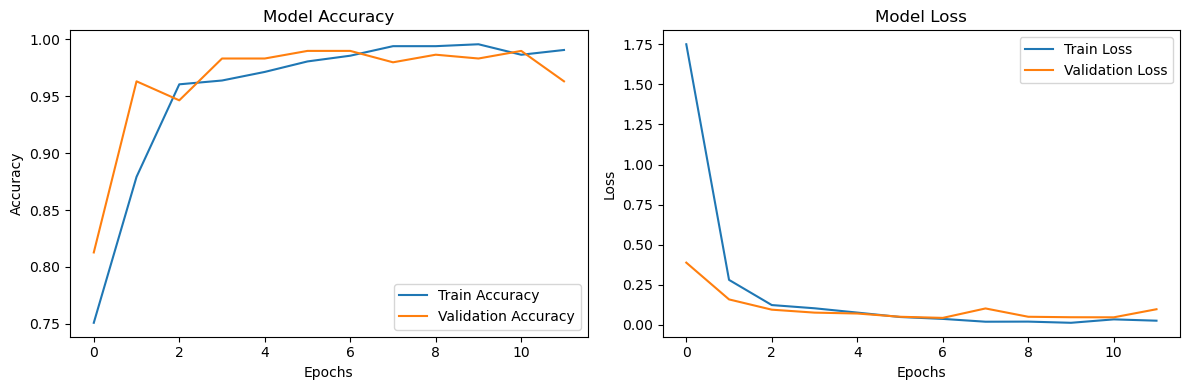

In [8]:
if 'model_cnn' in locals() and 'X_train_split' in locals():
    epochs = 15
    batch_size = 32

    print(f"\nStarting CNN training for {epochs} epochs...")

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("../models_trained/cnn/best_cnn_model.keras", save_best_only=True, monitor="val_loss")
    ]

    history = model_cnn.fit(
        X_train_split,
        y_train_split,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val_split, y_val_split),
        callbacks=callbacks,
        verbose=1
    )
    print("CNN Training finished.")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Cannot train CNN model, model or data splits not available.")

In [9]:
if 'model_cnn' in locals() and X_test_reshaped is not None and test_ids is not None:
    print("\nPredicting on test data...")
    predictions_prob = model_cnn.predict(X_test_reshaped)

    predictions_class = np.argmax(predictions_prob, axis=1)
    print(f"Predictions generated. Shape: {predictions_class.shape}")

    submission_cnn_df = pd.DataFrame({'ID': test_ids, 'target': predictions_class})

    submission_cnn_df = submission_cnn_df.sort_values(by='ID', ascending=True)
    print("Submission file sorted by ID.")

    submissions_dir = '../submissions/'
    submission_filename_cnn = "cnn_submission.csv"
    submission_path_cnn = os.path.join(submissions_dir, submission_filename_cnn)
    os.makedirs(submissions_dir, exist_ok=True)

    submission_cnn_df.to_csv(submission_path_cnn, index=False)
    print(f"Submission file saved: {submission_path_cnn}")

else:
     print("Cannot generate test predictions. Model, test data, or test IDs missing.")


Predicting on test data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predictions generated. Shape: (120,)
Submission file sorted by ID.
Submission file saved: ../submissions/cnn_submission.csv
